# Lab 6 — Morphological Image Processing
**Course:** ARTI407 – Image Processing  
**College of Computer Science and Information Technology**  
**Imam Abdulrahman Bin Faisal University**

This notebook covers:
1. **Task 1** — Create a binary test image with shapes and noise
2. **Task 2** — Define a structuring element
3. **Assessment Task 1** — Apply erosion, dilation, opening, closing using the 5×5 square kernel
4. **Assessment Task 2** — Apply the same operations using a circular kernel
5. **Assessment Task 3** — Compare the results


## Setup — Import libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

---
## Task 1 — Create a Binary Image with Shapes and Noise

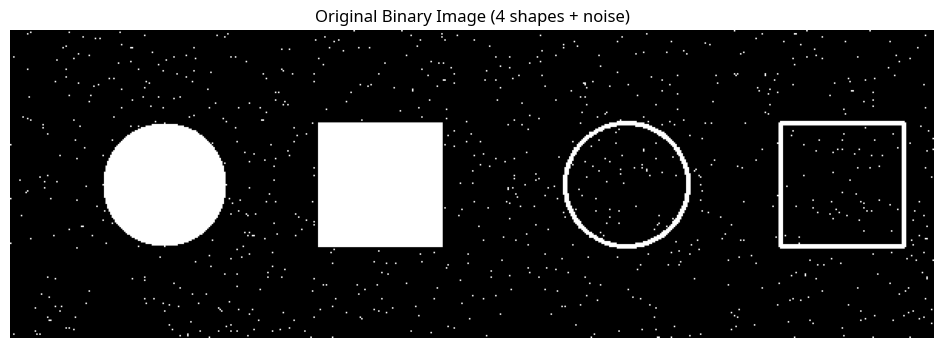

In [2]:
# Create a binary image with shapes and noise
image = np.zeros((200, 600), dtype=np.uint8)
cv2.circle(image, (100, 100), 40, 255, -1)              # Solid circle (filled)
cv2.rectangle(image, (200, 60), (280, 140), 255, -1)    # Solid rectangle (filled)
cv2.circle(image, (400, 100), 40, 255, 2)               # Hollow circle (outline)
cv2.rectangle(image, (500, 60), (580, 140), 255, 2)     # Hollow rectangle (outline)

# Add small noise (1000 random white pixels)
np.random.seed(0)
for _ in range(1000):
    x, y = np.random.randint(0, 600), np.random.randint(0, 200)
    image[y, x] = 255

plt.figure(figsize=(12, 4))
plt.imshow(image, cmap='gray')
plt.title('Original Binary Image (4 shapes + noise)')
plt.axis('off')
plt.show()

---
## Task 2 — Define the Structuring Element (5×5 Square Kernel)

In [3]:
kernel = np.ones((5, 5), np.uint8)
print("Square kernel (5×5):")
print(kernel)

Square kernel (5×5):
[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


---
## Assessment Task 1 — Apply Erosion, Dilation, Opening, Closing (Square Kernel)

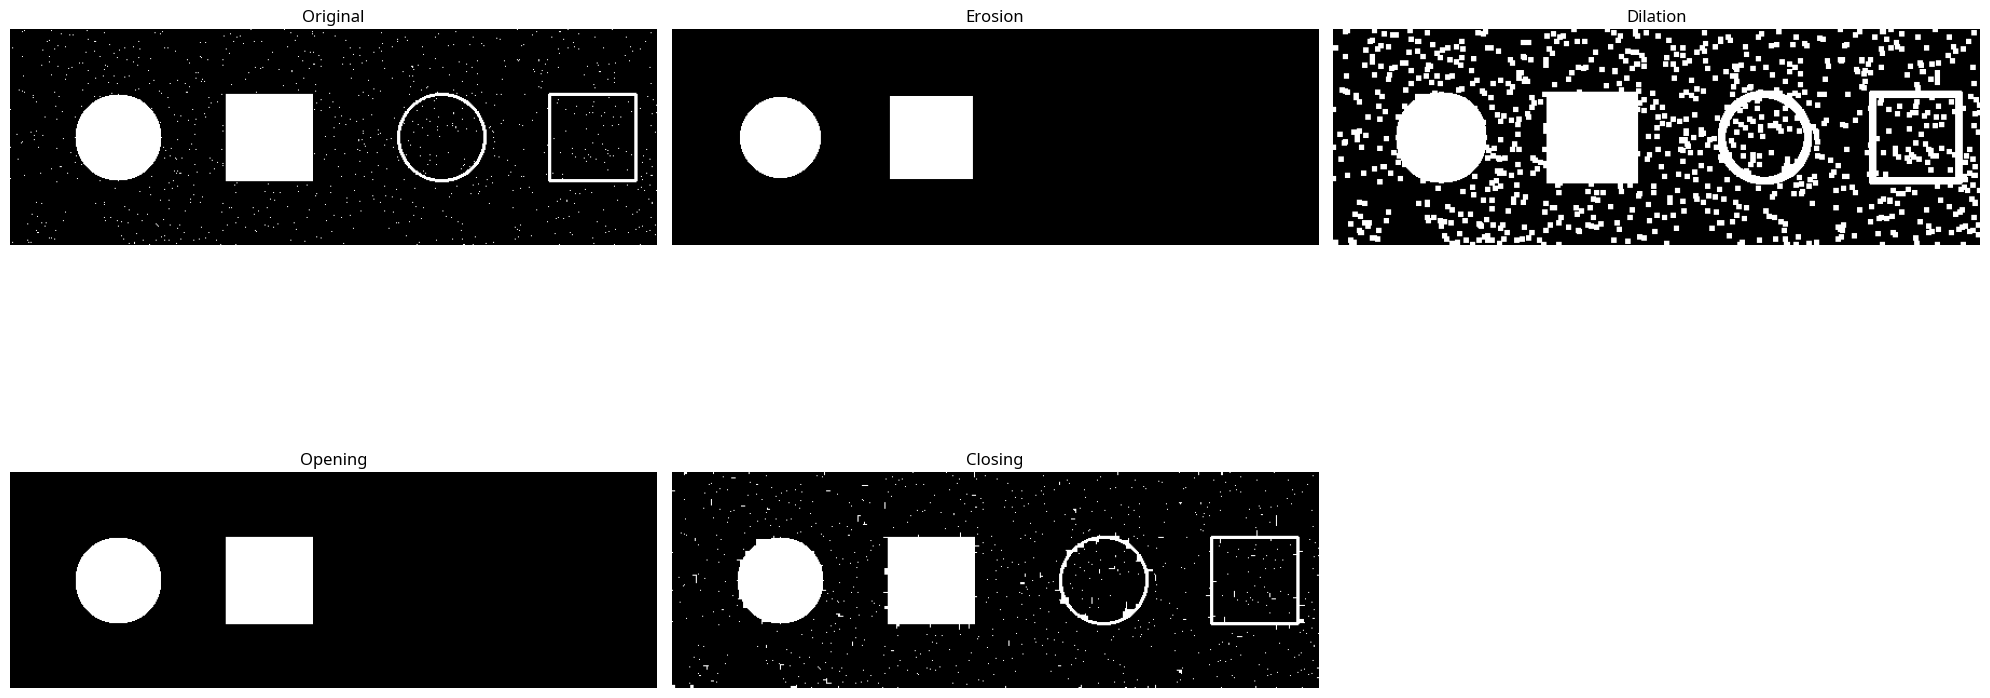

In [4]:
# Applying morphological operations with square kernel
erosion = cv2.erode(image, kernel, iterations=1)
dilation = cv2.dilate(image, kernel, iterations=1)
opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

# Plotting the results
titles = ['Original', 'Erosion', 'Dilation', 'Opening', 'Closing']
images = [image, erosion, dilation, opening, closing]

plt.figure(figsize=(20, 10))
for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

## Assessment Task 2 — Repeat with a Circular Kernel

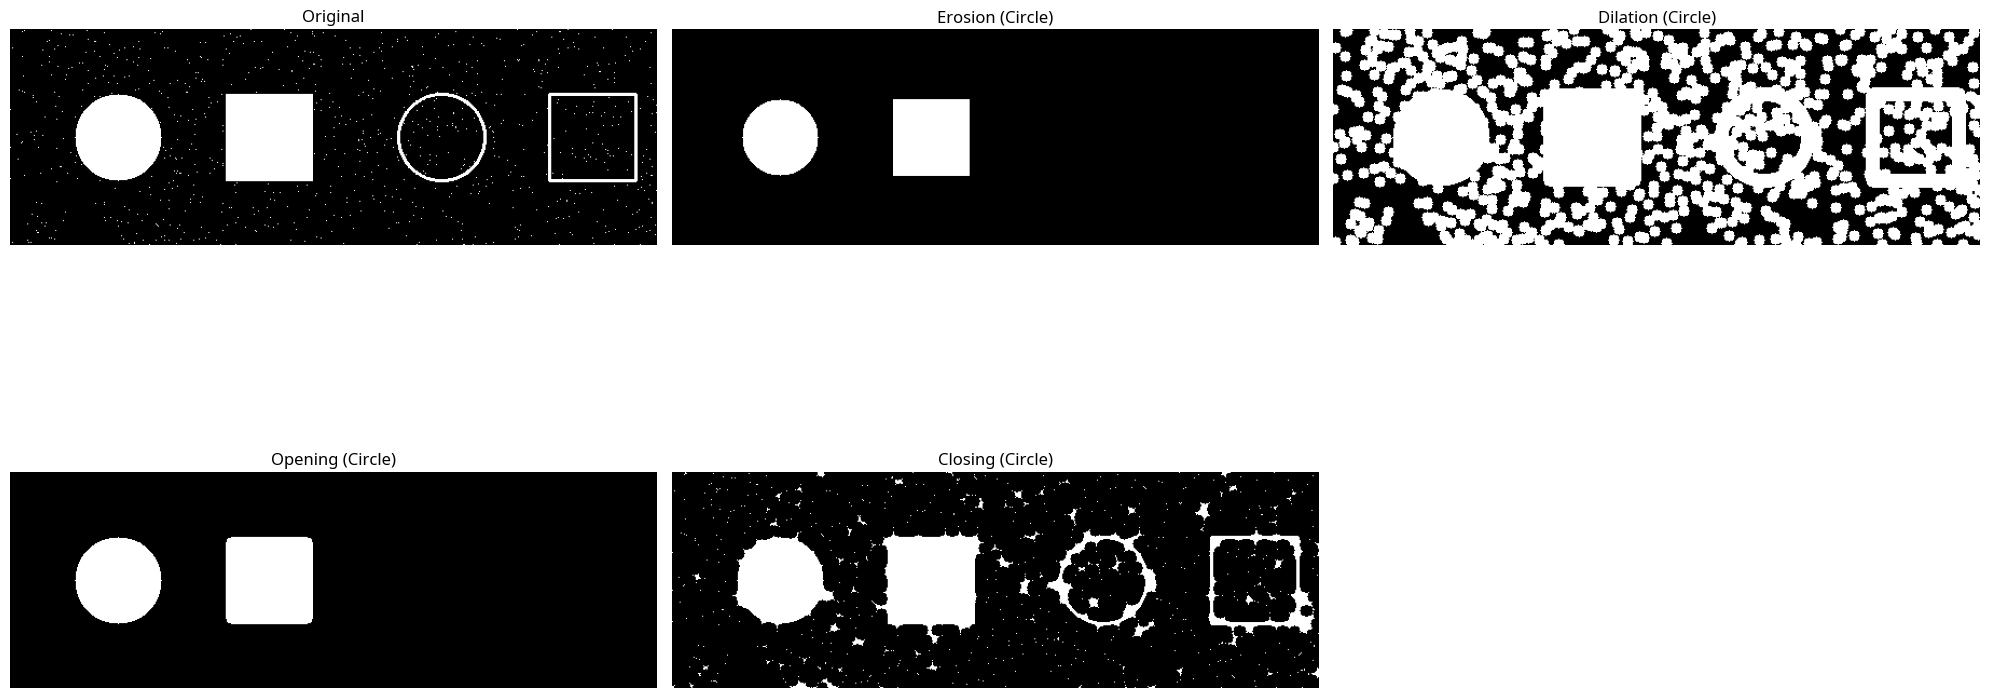

In [5]:
def circular_structuring_element(radius):
    size = 2 * radius + 1
    kernel = np.zeros((size, size), dtype=np.uint8)
    cv2.circle(kernel, (radius, radius), radius, 1, -1)
    return kernel

radius = 5
circle_kernel = circular_structuring_element(radius)

# Applying morphological operations with circular kernel
erosion_c = cv2.erode(image, circle_kernel, iterations=1)
dilation_c = cv2.dilate(image, circle_kernel, iterations=1)
opening_c = cv2.morphologyEx(image, cv2.MORPH_OPEN, circle_kernel)
closing_c = cv2.morphologyEx(image, cv2.MORPH_CLOSE, circle_kernel)

# Plotting the results
titles_c = ['Original', 'Erosion (Circle)', 'Dilation (Circle)', 'Opening (Circle)', 'Closing (Circle)']
images_c = [image, erosion_c, dilation_c, opening_c, closing_c]

plt.figure(figsize=(20, 10))
for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.imshow(images_c[i], cmap='gray')
    plt.title(titles_c[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

## Assessment Task 3 — Difference Between Square vs Circular Kernel

**Answer:**
1. **Shape Preservation:** The circular kernel preserves the roundness of the circular shapes much better than the square kernel. The square kernel tends to make circular objects look slightly more "blocky" or squared at the edges after multiple iterations or with larger sizes.
2. **Directional Bias:** The square kernel has a slight directional bias towards corners, whereas the circular kernel is more uniform in all directions (isotropic). 
3. **Resulting Size:** Since the circular kernel (radius 5) is effectively larger in area than a 5x5 square kernel, the erosion effect is stronger (shrinks more) and the dilation effect is stronger (grows more) compared to the 5x5 square kernel.